<a href="https://colab.research.google.com/github/Wintxrxr/Machine-Learning-/blob/main/Sensor_Perception_on_UAV_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)

X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigree  Age  Outcome  
0             0.627   50        1  
1             0.351   31        0  
2             0.672   32        1  
3             0.167   21        0  
4             2.288   33        1  
(768, 9)


In [ ]:
X_scaled = scaler.fit_transform(X)
# The scalar is fitted on the entire dataset before splitting into training and test sets.
# This means the scaling statistics are influenced by the test data which leaks information from the test set into the training process.
# As a result, the evaluation becomes biased and overly optimistic.

In [2]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Correct Accuracy:", accuracy_score(y_test, y_pred))

Correct Accuracy: 0.7532467532467533


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Leaky Accuracy:", accuracy_score(y_test, y_pred))

Leaky Accuracy: 0.7532467532467533


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

results = []

for seed in range(10):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append(acc)

print("Accuracies:", results)
print("Mean:", np.mean(results))
print("Std Dev:", np.std(results))

Accuracies: [0.8246753246753247, 0.7792207792207793, 0.7662337662337663, 0.7337662337662337, 0.8116883116883117, 0.7987012987012987, 0.7922077922077922, 0.7857142857142857, 0.7987012987012987, 0.7467532467532467]
Mean: 0.7837662337662337
Std Dev: 0.02678128652896271


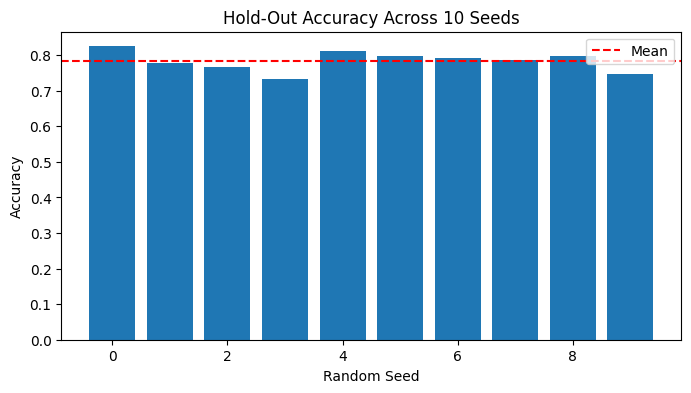

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(range(10), results)

plt.axhline(y=np.mean(results), color='red', linestyle='--', label='Mean')

plt.xlabel("Random Seed")
plt.ylabel("Accuracy")
plt.title("Hold-Out Accuracy Across 10 Seeds")

plt.legend()

plt.show()



Trusting a single hold-out split is unreliable because the accuracy varies depending on how the dataset is split. the variation across different random seeds shows that performance estimates can fluctuate noticebly.
The standard deviation indicates the amount of variability in the model's performnce estimate. Therefore, relying on a single split could give an overly optimistic or pessimistic evaluation.



In [9]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def run_kfold(X, y, k):

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []

    for train_idx, test_idx in kf.split(X):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = LogisticRegression(max_iter=200)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        fold_scores.append(acc)

    return fold_scores

In [10]:
scores_5fold = run_kfold(X, y, 5)
scores_10fold = run_kfold(X, y, 10)

print("5-Fold Scores:", scores_5fold)
print("Mean:", np.mean(scores_5fold))
print("Std:", np.std(scores_5fold))

print()

print("10-Fold Scores:", scores_10fold)
print("Mean:", np.mean(scores_10fold))
print("Std:", np.std(scores_10fold))

5-Fold Scores: [0.7532467532467533, 0.7857142857142857, 0.7532467532467533, 0.803921568627451, 0.7450980392156863]
Mean: 0.7682454800101859
Std: 0.02264363087553596

10-Fold Scores: [0.7012987012987013, 0.8051948051948052, 0.7272727272727273, 0.8441558441558441, 0.8311688311688312, 0.6753246753246753, 0.8571428571428571, 0.7792207792207793, 0.7105263157894737, 0.7763157894736842]
Mean: 0.7707621326042379
Std: 0.06102327014484286


A lower standard deviation indicates that the model's performance estimate is more stable across different training/test splits. Compared to Hold-Out evaluation, K-Fold cross-validation usually has lower variance because it averages performance across multiple folds. This makes K-Fold a more reliable method for estimating how the model will perform on unseen data.

In [12]:
from sklearn.model_selection import KFold, StratifiedKFold

def check_class_distribution(X, y, k, stratified=False):

    if stratified:
        splitter = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    else:
        splitter = KFold(n_splits=k, shuffle=True, random_state=42)

    print(f"\n{'Stratified' if stratified else 'Regular'} {k}-Fold -- Class 1 % per test fold:")

    for i, (train_idx, test_idx) in enumerate(splitter.split(X, y if stratified else None)):

        y_test_fold = y[test_idx]

        class1_pct = np.mean(y_test_fold) * 100

        print(f"Fold {i+1}: {class1_pct:.1f}% class 1")


In [13]:
check_class_distribution(X, y, 5, stratified=False)
check_class_distribution(X, y, 5, stratified=True)


Regular 5-Fold -- Class 1 % per test fold:
Fold 1: 35.7% class 1
Fold 2: 30.5% class 1
Fold 3: 39.6% class 1
Fold 4: 30.7% class 1
Fold 5: 37.9% class 1

Stratified 5-Fold -- Class 1 % per test fold:
Fold 1: 35.1% class 1
Fold 2: 35.1% class 1
Fold 3: 35.1% class 1
Fold 4: 34.6% class 1
Fold 5: 34.6% class 1


In [15]:
from sklearn.model_selection import StratifiedKFold

def run_stratified_kfold(X, y, k):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    scores = []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = LogisticRegression(max_iter=200)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        scores.append(accuracy_score(y_test, y_pred))

    return scores


In [16]:
strat5 = run_stratified_kfold(X, y, 5)
strat10 = run_stratified_kfold(X, y, 10)

print("Stratified 5-Fold Mean:", np.mean(strat5))
print("Stratified 10-Fold Mean:", np.mean(strat10))

Stratified 5-Fold Mean: 0.7746965452847806
Stratified 10-Fold Mean: 0.775974025974026


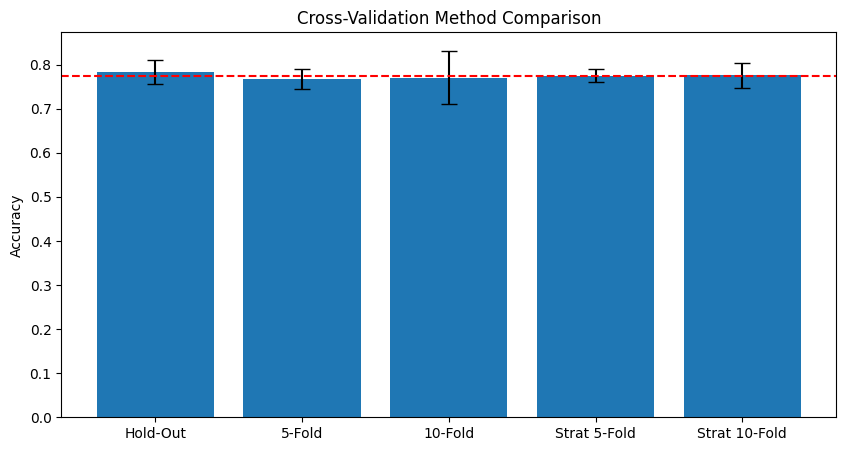

In [17]:
methods = ['Hold-Out', '5-Fold', '10-Fold', 'Strat 5-Fold', 'Strat 10-Fold']

means = [
    np.mean(results),
    np.mean(scores_5fold),
    np.mean(scores_10fold),
    np.mean(strat5),
    np.mean(strat10)
]

stds = [
    np.std(results),
    np.std(scores_5fold),
    np.std(scores_10fold),
    np.std(strat5),
    np.std(strat10)
]

plt.figure(figsize=(10,5))

plt.bar(methods, means, yerr=stds, capsize=6)

plt.axhline(y=np.mean(means), color='red', linestyle='--')

plt.ylabel("Accuracy")
plt.title("Cross-Validation Method Comparison")

plt.show()



Because a single random split might produce deceptive results, the senior engineer's claim of obtaining 80% accuracy from a single Hold-Out split is not entirely reliable. Our experiments with cross-validation and multiple Hold-Out runs demonstrate that the model's performance varies with data splitting. The average of 77–79% that comes from cross-validation techniques is a more trustworthy estimate of accuracy. Because it maintains the class distribution across folds, which is crucial considering the moderate class disparity, Stratified K-Fold is the best method among those assessed for this dataset. This results in performance estimates that are more uniform and representative. To make sure the model works well in both classes, other metrics like precision, recall, and ROC-AUC should be assessed before the model is deemed production-ready.